<a href="https://colab.research.google.com/github/rottemdav/projectA/blob/main/video_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
#imports 
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq



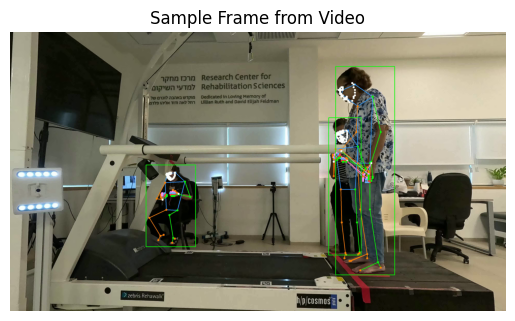

In [2]:
# print a sample frame from the video
# /home/projects/sipl-prj10496/project_files/data/output/20260526_183051/NL129_3_3_pose_20260526_183051_0_to_end.mp4
video_path = "/home/projects/sipl-prj10496/project_files/data/output/20260526_183051/NL129_3_3_pose_20260526_183051_0_to_end.mp4"
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
if ret:
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Sample Frame from Video')
    plt.show()
else:
    print("Failed to read video.")
cap.release()

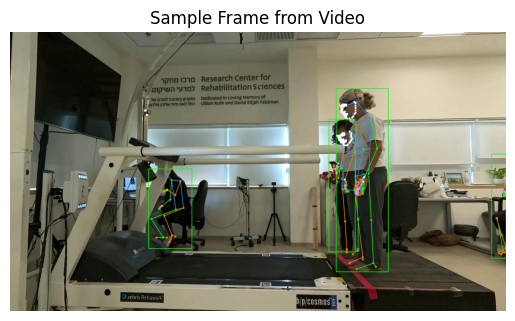

In [5]:
# print a sample frame from the video
# /home/projects/sipl-prj10496/project_files/data/output/20260526_180118/HC65_3_keypoints_20260526_180118_0_to_end.json
video_path = "/home/projects/sipl-prj10496/project_files/data/output/20260526_180118/HC65_3_pose_20260526_180118_0_to_end.mp4"
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
if ret:
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Sample Frame from Video')
    plt.show()
else:
    print("Failed to read video.")
cap.release()

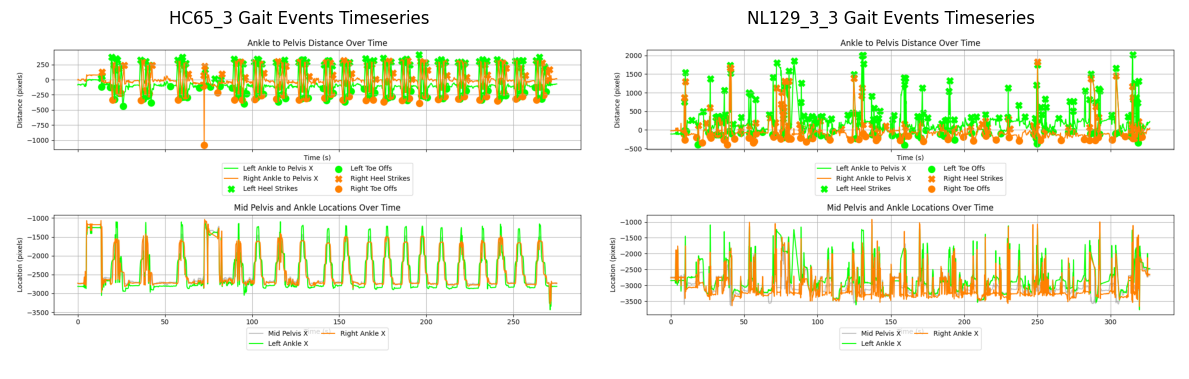

In [7]:
#show these images side by side: 
# image 1: /home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260526_220109/HC65_3_gait_events_timeseries_1.png
# image 2: /home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260526_221113/NL129_3_3_gait_events_timeseries.png
image1_path = "/home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260526_220109/HC65_3_gait_events_timeseries_1.png"
image2_path = "/home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260526_221113/NL129_3_3_gait_events_timeseries.png"
image1 = cv2.imread(image1_path)
image2 = cv2.imread(image2_path)
image1_rgb = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
image2_rgb = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image1_rgb)
plt.axis('off')
plt.title('HC65_3 Gait Events Timeseries')
plt.subplot(1, 2, 2)
plt.imshow(image2_rgb)
plt.axis('off')
plt.title('NL129_3_3 Gait Events Timeseries')
plt.tight_layout()
plt.show()  

In [15]:
# /home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260526_221113/NL129_3_3_steps.parquet
# /home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260526_220109/HC65_3_steps.parquet

NL129_steps = pd.read_parquet("/home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260526_221113/NL129_3_3_steps.parquet")
NL129_summary = pd.read_parquet("/home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260526_221113/NL129_3_3_summary.parquet")
HC65_steps = pd.read_parquet("/home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260526_220109/HC65_3_steps.parquet")
HC65_summary = pd.read_parquet("/home/projects/sipl-prj10496/project_files/outputs/hrnet_wholebody_output/20260526_220109/HC65_3_summary.parquet")

print("Steps DataFrame:")
print(NL129_steps.head())

print("\nSummary DataFrame:")
print(NL129_summary)

Steps DataFrame:
    video_id      run_hash_id  frame_index  side  event_index  hs_frame  \
0  NL129_3_3  20260526_221113          553  left            0       553   
1  NL129_3_3  20260526_221113          594  left            1       594   
2  NL129_3_3  20260526_221113          843  left            2       843   
3  NL129_3_3  20260526_221113         1330  left            3      1330   
4  NL129_3_3  20260526_221113         1616  left            4      1616   

   to_frame  step_time_s  stance_time_s  swing_time_s  step_length_px  valid  
0       569     0.683333       0.266667      0.416667      115.758301   True  
1       644     4.066667       0.833333      3.316667      658.904175   True  
2      1109     3.250000       4.433333      3.683333      360.374512   True  
3      1547     2.916667       3.616667      1.150000      558.429688   True  
4      1632     0.133333       0.266667      3.483333     1193.911255   True  

Summary DataFrame:
    video_id      run_hash_id  num_fra

In [17]:
from IPython.display import display

display(NL129_steps.groupby("side")[["step_time_s", "step_length_px"]].describe())
display(HC65_steps.groupby("side")[["step_time_s", "step_length_px"]].describe())

step_time_s                                                              \
            count      mean       std       min       25%       50%       75%   
side                                                                            
left         63.0  1.708995  2.472276  0.016667  0.241667  0.683333  2.166667   
right        60.0  3.425000  3.388131  0.016667  0.608333  2.616667  5.395833   

                 step_length_px                                     \
             max          count        mean         std        min   
side                                                                 
left   11.233334           64.0  666.146118  523.611450  45.090698   
right  13.083333           60.0  245.432083  236.117752   7.502197   

                                                         
              25%         50%          75%          max  
side                                                     
left   285.032379  467.689331  1066.048248  2096.548584  
right   84.599091  151.482910   323.847778   995.656738

step_time_s                                                          \
            count      mean       std       min       25%   50%       75%   
side                                                                        
left         60.0  3.013333  3.088442  0.216667  0.983333  1.15  5.279167   
right        60.0  1.400000  1.386945  0.350000  0.929167  1.05  1.325000   

                 step_length_px                                     \
             max          count        mean         std        min   
side                                                                 
left   14.766666           62.0  408.503052  138.220520  23.938232   
right   9.633333           60.0  358.687927  127.870621  70.561279   

                                                       
              25%         50%         75%         max  
side                                                   
left   375.169220  424.482605  513.207214  668.808350  
right  257.996948  410.101318  452.179871  545.717285

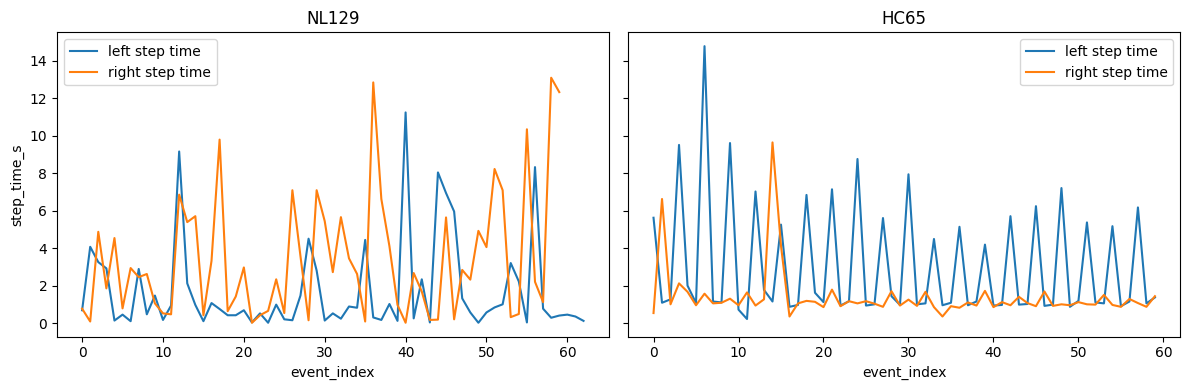

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

NL129_steps.hist(column=["step_time_s", "step_length_px"], by="side", bins=30, ax=axes[0])
axes[0].set_title("NL129")

HC65_steps.hist(column=["step_time_s", "step_length_px"], by="side", bins=30, ax=axes[1])
axes[1].set_title("HC65")

plt.tight_layout()
plt.show()

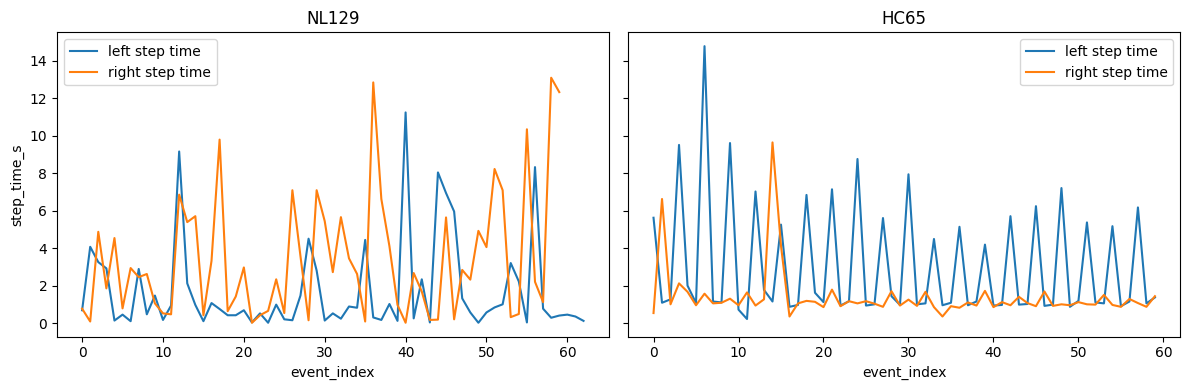

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for side, df in NL129_steps.groupby("side"):
    df = df.sort_values("event_index")
    axes[0].plot(df["event_index"], df["step_time_s"], label=f"{side} step time")
axes[0].set_title("NL129")
axes[0].set_xlabel("event_index")
axes[0].set_ylabel("step_time_s")
axes[0].legend()

for side, df in HC65_steps.groupby("side"):
    df = df.sort_values("event_index")
    axes[1].plot(df["event_index"], df["step_time_s"], label=f"{side} step time")
axes[1].set_title("HC65")
axes[1].set_xlabel("event_index")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:

print("left rows:", (HC65_steps["side"] == "left").sum())
print("right rows:", (HC65_steps["side"] == "right").sum())

# Optional: verify non-null counts for each field by side
for side in ["left", "right"]:
    s = HC65_steps[HC65_steps["side"] == side]
    print(f"\n{side} non-null counts:")
    print(s[["hs_frame", "to_frame", "step_time_s", "stance_time_s", "swing_time_s", "step_length_px"]].notna().sum())

NL129_steps = NL129_steps.sort_values("frame_index")
pd.set_option("display.max_rows", None)
display(NL129_steps)


left rows: 62
right rows: 60

left non-null counts:
hs_frame          62
to_frame          62
step_time_s       60
stance_time_s     62
swing_time_s      62
step_length_px    62
dtype: int64

right non-null counts:
hs_frame          60
to_frame          60
step_time_s       60
stance_time_s     60
swing_time_s      60
step_length_px    60
dtype: int64


,video_id,run_hash_id,frame_index,side,event_index,hs_frame,to_frame,step_time_s,stance_time_s,swing_time_s,step_length_px,valid
0,NL129_3_3,20260526_221113,553,left,0,553,569,0.683333,0.266667,0.416667,115.758301,True
64,NL129_3_3,20260526_221113,553,right,0,553,537,0.766667,0.516667,0.266667,115.758301,True
1,NL129_3_3,20260526_221113,594,left,1,594,644,4.066667,0.833333,3.316667,658.904175,True
65,NL129_3_3,20260526_221113,599,right,1,599,584,0.083333,7.600000,0.250000,120.174805,True
2,NL129_3_3,20260526_221113,843,left,2,843,1109,3.250000,4.433333,3.683333,360.374512,True
66,NL129_3_3,20260526_221113,1135,right,2,1135,1055,4.866667,2.650000,1.333333,82.591797,True
3,NL129_3_3,20260526_221113,1330,left,3,1330,1547,2.916667,3.616667,1.150000,558.429688,True
67,NL129_3_3,20260526_221113,1441,right,3,1441,1294,1.850000,2.550000,2.450000,175.757080,True
68,NL129_3_3,20260526_221113,1608,right,4,1608,1594,4.533333,0.683333,0.233333,418.737061,True
4,NL129_3_3,20260526_221113,1616,left,4,1616,1632,0.133333,0.266667,3.483333,1193.911255,True
